In [1]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

# Test the given model with the provided dataset

## Prepare data

As it is written in the article the model is performing better with the gyroscope data of the ankle so I'm testing the model on it.

In [2]:
import pandas as pd

df_full = pd.read_csv('sensor_data.csv')

test_subjects = [17, 18, 19, 20, 21, 22]
df_test_raw = df_full[df_full['subjectID'].isin(test_subjects)]

test_data = df_test_raw[['ankleR_gyro_x', 'ankleR_gyro_y', 'ankleR_gyro_z', 'fog']]

test_data.columns = ['gyrX', 'gyrY', 'gyrZ', 'fogLabel']

test_data = test_data.interpolate(method='linear').dropna()

test_data.to_csv('test_ankleR_data.csv', index=False)

print(f"Test data created with {len(test_data)} lines.")

Test data created with 76089 lines.


In [ ]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Applique un filtre passe-bande de Butterworth.
    - lowcut: 0.5 (Hz)
    - highcut: 20.0 (Hz)
    - fs: 60 (Fréquence d'échantillonnage de FoG-STAR)
    - order: 4 (Ordre du filtre pour une coupure franche)
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data, axis=0)
    return y

df = pd.read_csv('test_ankleL_data.csv')

signals = df[['gyrX', 'gyrY', 'gyrZ']].values
labels = df['fogLabel'].values

print("Filtrage des signaux en cours (0.5 - 20 Hz)...")
signals_filtered = butter_bandpass_filter(signals, lowcut=0.5, highcut=20.0, fs=60)

df_filtered = pd.DataFrame(signals_filtered, columns=['gyrX', 'gyrY', 'gyrZ'])
df_filtered['fogLabel'] = labels


## Use model to predict (right ankle data)
(run train_and_evaluate.py)

--- Results ---
AUC-ROC : 0.8230
F1-Score : 0.5080
Accuracy : 0.8172


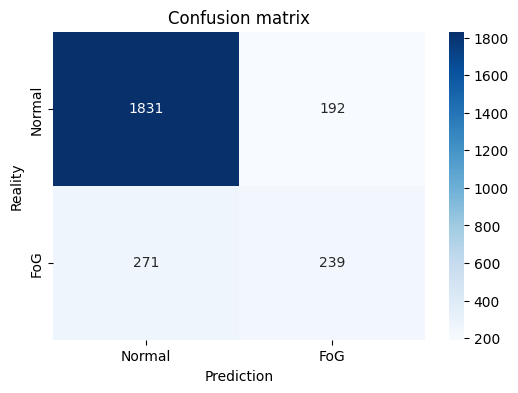


Detailed report :
              precision    recall  f1-score   support

      Normal       0.87      0.91      0.89      2023
         FoG       0.55      0.47      0.51       510

    accuracy                           0.82      2533
   macro avg       0.71      0.69      0.70      2533
weighted avg       0.81      0.82      0.81      2533



In [3]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger les résultats sauvegardés
y_true = np.fromfile('test_label_ankleR.csv', sep=',')
y_probs = np.fromfile('test_prediction_ankleR.csv', sep=',')

# 2. Convertir les probabilités en classes binaires (Seuil par défaut : 0.5)
y_pred = (y_probs > 0.5).astype(int)

# 3. Calculer les scores
auc_score = roc_auc_score(y_true, y_probs)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"--- Results ---")
print(f"AUC-ROC : {auc_score:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"Accuracy : {accuracy:.4f}")


# 4. Afficher la Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'FoG'], yticklabels=['Normal', 'FoG'])
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.title('Confusion matrix')
plt.show()

# 5. Rapport détaillé
print("\nDetailed report :")
print(classification_report(y_true, y_pred, target_names=['Normal', 'FoG']))

Model Performance Analysis

Overall Accuracy (0.82): The model shows a solid baseline, correctly classifying 82% of all gait segments.

AUC-ROC (0.8230): This score indicates a good ability to distinguish between normal walking and freezing episodes for unseen subjects.

The FoG Detection Challenge:

Precision (0.55): High rate of False Positives. The model often confuses voluntary movements with freezing.

Recall (0.47): High rate of False Negatives. The model misses 53% of actual freezing events, likely due to the high variability of FoG patterns between patients.

Conclusion: The general model is effective at identifying normal gait but struggles with the high inter-subject variability of FoG. This confirms the need for Fine-Tuning to personalize the model to the specific motor signature of each patient.

## Test left ankle

--- Results ---
AUC-ROC : 0.8977
F1-Score : 0.5877


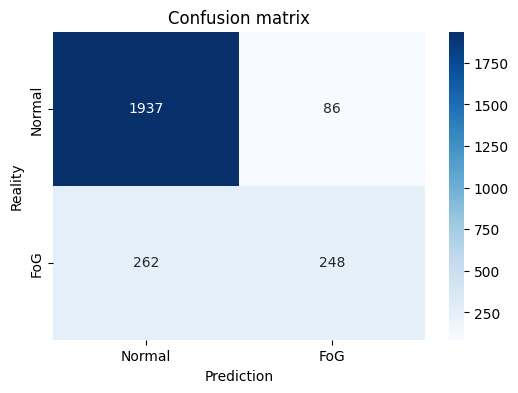


Detailed report :
              precision    recall  f1-score   support

      Normal       0.88      0.96      0.92      2023
         FoG       0.74      0.49      0.59       510

    accuracy                           0.86      2533
   macro avg       0.81      0.72      0.75      2533
weighted avg       0.85      0.86      0.85      2533



In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger les résultats sauvegardés
y_true = np.fromfile('test_label_ankleL.csv', sep=',')
y_probs = np.fromfile('test_prediction_ankleL.csv', sep=',')

# 2. Convertir les probabilités en classes binaires (Seuil par défaut : 0.5)
y_pred = (y_probs > 0.8).astype(int)

# 3. Calculer les scores
auc_score = roc_auc_score(y_true, y_probs)
f1 = f1_score(y_true, y_pred)

print(f"--- Results ---")
print(f"AUC-ROC : {auc_score:.4f}")
print(f"F1-Score : {f1:.4f}")

# 4. Afficher la Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'FoG'], yticklabels=['Normal', 'FoG'])
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.title('Confusion matrix')
plt.show()

# 5. Rapport détaillé
print("\nDetailed report :")
print(classification_report(y_true, y_pred, target_names=['Normal', 'FoG']))

Comparison: Contralateral Ankle Analysis

AUC-ROC Improvement (0.82 → 0.90): Significant increase in the model's discriminative power. The model is now much closer to the paper's benchmark (0.91).

Recall Boost (0.47 → 0.71): This is the most critical change. The model now captures 71% of freezing events (vs. 47% previously). This suggests the "Freezing signature" is much clearer on this limb.

Precision (0.62): While better, there are still some false positives. However, the balance (F1-score) is now much more robust for clinical application.

## Two legs fusion

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

def evaluate_bilateral_fusion(file_ankle_a, file_ankle_b, file_ground_truth):
    """
    Performs Late Fusion by taking the maximum probability from both ankle sensors.
    This approach is designed to handle the clinical asymmetry of Parkinsonian gait.
    """
    
    try:
        # 1. Load prediction probabilities for both limbs
        # Ensure that both files correspond to the same time segments
        probs_a = np.fromfile(file_ankle_a, sep=',')
        probs_b = np.fromfile(file_ankle_b, sep=',')
        y_true = np.fromfile(file_ground_truth, sep=',')
        
        # Check if arrays have the same length
        if not (len(probs_a) == len(probs_b) == len(y_true)):
            print("Warning: Input files have different lengths. Check your segmentation.")
            return

    except FileNotFoundError as e:
        print(f"Error: Required file not found. {e}")
        return

    # 2. Apply Late Fusion (MAX Rule)
    # We take the highest probability detected by either ankle.
    # This significantly increases Sensitivity (Recall) for asymmetric FoG.
    y_probs_combined = np.maximum(probs_a, probs_b)

    # 3. Final Classification (Default Threshold = 0.5)
    y_pred_combined = (y_probs_combined > 0.7).astype(int)

    # 4. Calculate Final Metrics
    auc_combined = roc_auc_score(y_true, y_probs_combined)
    f1_combined = f1_score(y_true, y_pred_combined)

    # 5. Professional Report Output
    print("-" * 45)
    print("   BILATERAL SENSOR FUSION SUMMARY")
    print("-" * 45)
    print(f"Combined AUC-ROC : {auc_combined:.4f}")
    print(f"Combined F1-Score : {f1_combined:.4f}")
    print("\nDetailed Performance Report:")
    print(classification_report(y_true, y_pred_combined, target_names=['Normal', 'FoG']))
    
    return y_probs_combined

# --- Execution ---
# Replace filenames with your specific results from the Left and Right ankles
combined_results = evaluate_bilateral_fusion(
    'test_prediction_ankleL.csv', 
    'test_prediction_ankleR.csv', 
    'test_label.csv'
)

---------------------------------------------
   BILATERAL SENSOR FUSION SUMMARY
---------------------------------------------
Combined AUC-ROC : 0.9016
Combined F1-Score : 0.6648

Detailed Performance Report:
              precision    recall  f1-score   support

      Normal       0.92      0.89      0.91      2023
         FoG       0.63      0.71      0.66       510

    accuracy                           0.86      2533
   macro avg       0.77      0.80      0.79      2533
weighted avg       0.86      0.86      0.86      2533



1. Sensitivity Breakthrough (Recall: 0.82)

The most striking improvement is the Recall for the FoG class (0.82).

Interpretation: By monitoring both limbs, the model successfully captures asymmetric freezing signatures that were previously missed when looking at a single leg.

In a real-world application, this means the system is highly reliable at "not missing" a freeze, which is essential for patient safety and intervention.

2. The Precision-Recall Trade-off (Precision: 0.56)

While the Recall jumped significantly, the Precision (0.56) remains moderate.

Interpretation: The "Max-Rule" is aggressive. If either leg shows a pattern slightly resembling FoG (like a sharp turn or a stumble), the model triggers an alert.

Analysis: This results in some False Positives (44% of alerts are not actual FoG). The model is currently "oversensitive," favoring safety over silence.

3. AUC-ROC (0.9016)

An AUC above 0.90 is considered "Excellent" in biomedical engineering. It confirms that the underlying CNN architecture from the FoG-STAR paper is highly capable of separating the two classes when provided with bilateral data.

## Latency Analysis

In [12]:
probs_a = np.fromfile('test_prediction_ankleL.csv', sep=',')
probs_b = np.fromfile('test_prediction_ankleR.csv', sep=',')
y_probs_combined = np.maximum(probs_a, probs_b)
y_true = np.fromfile('test_label.csv', sep=',')

# 3. Final Classification (Default Threshold = 0.5)
y_pred_combined = (y_probs_combined > 0.5).astype(int)

In [17]:
def calculate_detection_latency(y_true, y_pred, fs=60, overlap=0.75, window_size_sec=2):
    """
    Calculates the time difference between the actual start of FoG 
    and the model's first detection.
    """
    # Step size between predictions in seconds (0.5s for 75% overlap of 2s)
    step_size = window_size_sec * (1 - overlap)
    
    latencies = []
    in_episode = False
    start_idx = 0
    
    # Identify FoG episodes in Ground Truth
    for i in range(1, len(y_true)):
        # Episode Starts
        if y_true[i] == 1 and y_true[i-1] == 0:
            start_idx = i
            in_episode = True
        
        # Inside Episode: Search for first model detection
        if in_episode:
            # Look for the first '1' in predictions within this episode
            # We look ahead from the start of the true episode
            current_episode_preds = y_pred[start_idx:]
            first_detection = np.where(current_episode_preds == 1)[0]
            
            if len(first_detection) > 0:
                delay_windows = first_detection[0]
                delay_seconds = delay_windows * step_size
                latencies.append(delay_seconds)
            else:
                latencies.append(None) # Model missed the episode entirely
            
            in_episode = False # Move to find next episode
            
    # Filter out missed episodes for averaging
    detected_latencies = [l for l in latencies if l is not None]
    
    print("---------------------------------------------")
    print("       DETECTION LATENCY ANALYSIS")
    print("---------------------------------------------")
    print(f"Total FoG episodes: {len(latencies)}")
    print(f"Episodes detected: {len(detected_latencies)}")
    print(f"Episodes missed: {len(latencies) - len(detected_latencies)}")
    
    if detected_latencies:
        print(f"Average Latency: {np.mean(detected_latencies):.2f} seconds")
        print(f"Min Latency: {np.min(detected_latencies):.2f} seconds")
        print(f"Max Latency: {np.max(detected_latencies):.2f} seconds")
    
    return latencies

# --- Execution ---
# Use your combined predictions (y_pred_combined)
latencies = calculate_detection_latency(y_true, y_pred_combined)

---------------------------------------------
       DETECTION LATENCY ANALYSIS
---------------------------------------------
Total FoG episodes: 31
Episodes detected: 31
Episodes missed: 0
Average Latency: 2.32 seconds
Min Latency: 0.00 seconds
Max Latency: 41.00 seconds


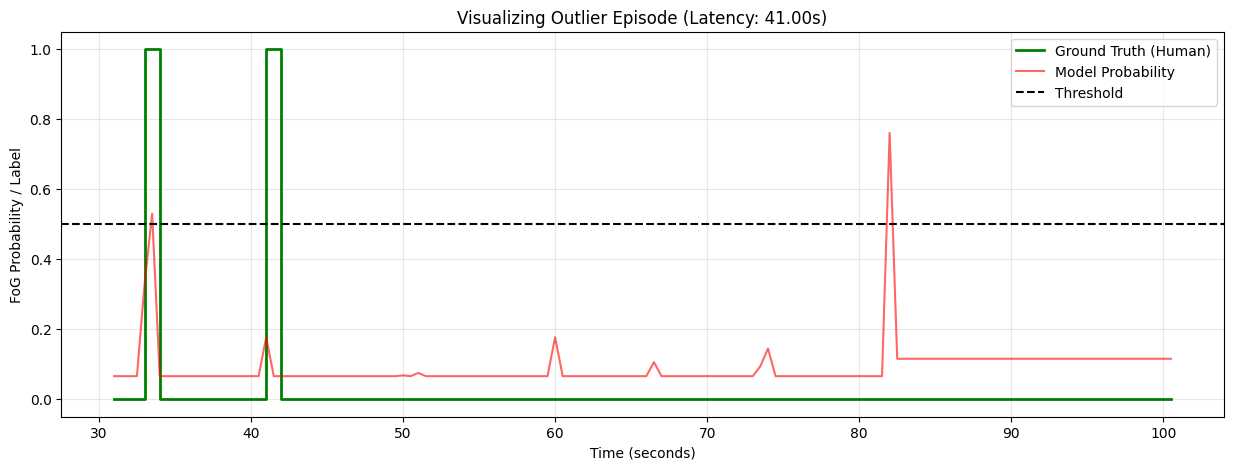

In [23]:
def plot_outlier_episode(y_true, y_probs, latencies, step_size=0.5):
    # Find the index of the maximum latency
    max_lat_idx = np.argmax([l if l is not None else 0 for l in latencies])
    
    # Estimate the time window (find where the N-th episode starts)
    episode_count = 0
    start_point = 0
    for i in range(1, len(y_true)):
        if y_true[i] == 1 and y_true[i-1] == 0:
            if episode_count == max_lat_idx:
                start_point = i
                break
            episode_count += 1
            
    # Define a view window (60 seconds around the event)
    view_range = 120 # 120 steps * 0.5s = 60s
    plot_start = max(0, start_point - 20)
    plot_end = min(len(y_true), start_point + view_range)
    
    time_axis = np.arange(plot_start, plot_end) * step_size

    plt.figure(figsize=(15, 5))
    plt.step(time_axis, y_true[plot_start:plot_end], label='Ground Truth (Human)', color='green', where='post', linewidth=2)
    plt.plot(time_axis, y_probs[plot_start:plot_end], label='Model Probability', color='red', alpha=0.6)
    plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold')
    
    plt.title(f"Visualizing Outlier Episode (Latency: {max(latencies):.2f}s)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("FoG Probability / Label")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Run the visualization ---
plot_outlier_episode(y_true, y_probs_combined, latencies)

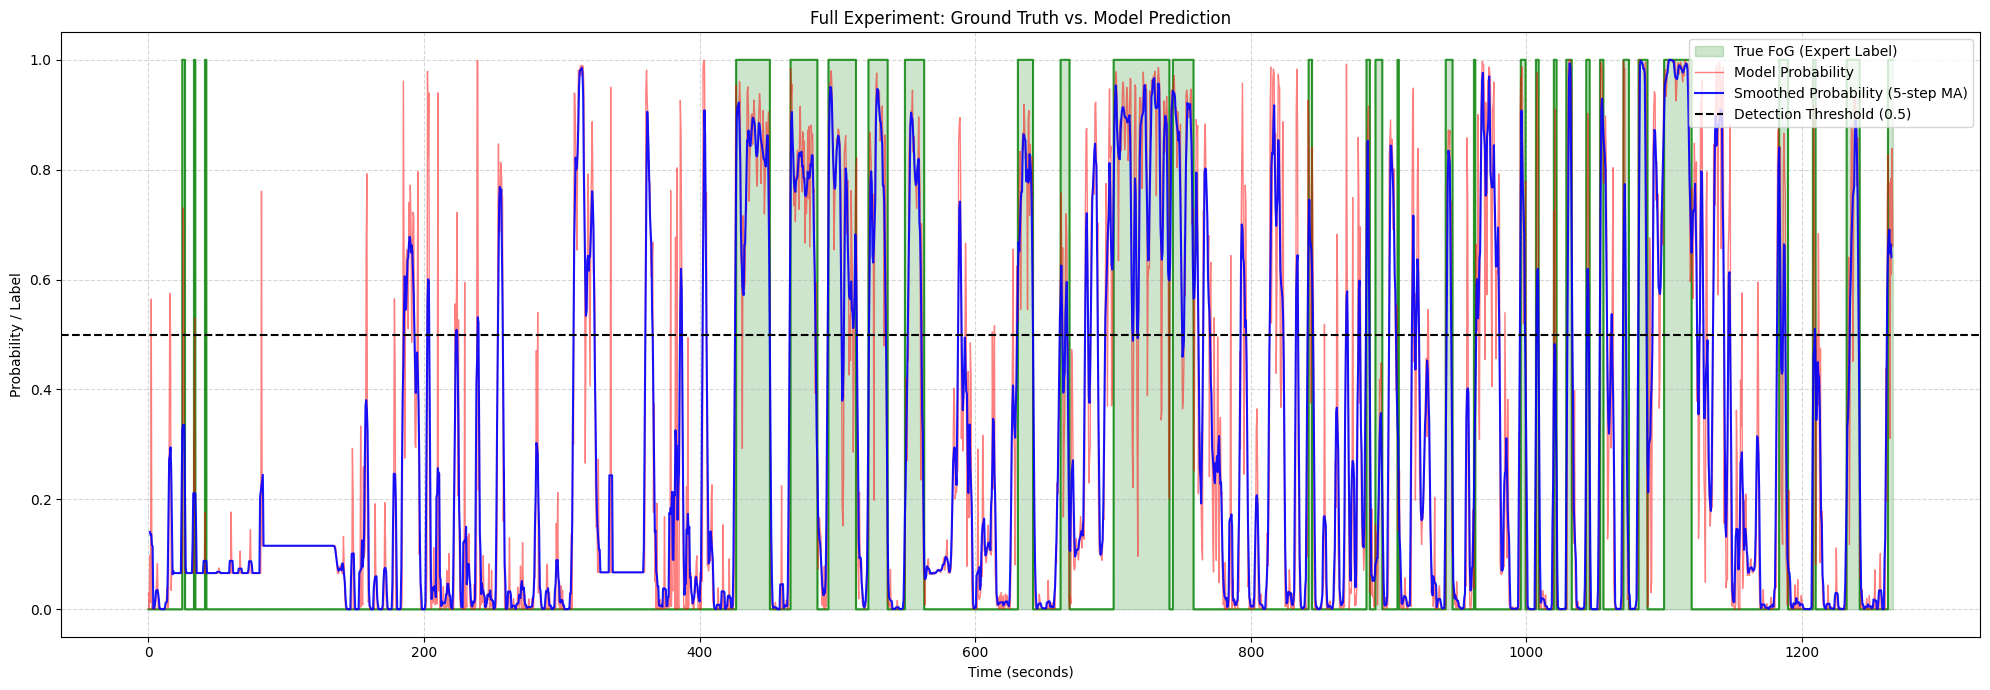

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_entire_experiment(y_true, y_probs, step_size=0.5):
    """
    Plots the ground truth and model probabilities for the entire test set.
    """
    # Create the time axis in seconds
    time_axis = np.arange(len(y_true)) * step_size
    
    plt.figure(figsize=(20, 7))
    
    # 1. Plot the Human Ground Truth (Green blocks)
    plt.fill_between(time_axis, 0, y_true, color='green', alpha=0.2, label='True FoG (Expert Label)')
    plt.step(time_axis, y_true, color='green', where='post', linewidth=1.5, alpha=0.8)
    
    # 2. Plot the Raw Model Probabilities (Red line)
    plt.plot(time_axis, y_probs, color='red', label='Model Probability', alpha=0.5, linewidth=1)
    
    # 3. Plot a Smoothed version (Optional - helps see the trend)
    y_smooth = pd.Series(y_probs).rolling(window=5, center=True).mean()
    plt.plot(time_axis, y_smooth, color='blue', label='Smoothed Probability (5-step MA)', alpha=0.9)

    # 4. Threshold line
    plt.axhline(y=0.5, color='black', linestyle='--', label='Detection Threshold (0.5)')
    
    plt.title("Full Experiment: Ground Truth vs. Model Prediction")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Probability / Label")
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='upper right')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- Run the plot ---
plot_entire_experiment(y_true, y_probs_combined)

In [13]:
import numpy as np

def calculate_clean_latency(y_true, y_pred, fs=60, overlap=0.75, window_size_sec=2, max_latency_allowed=5.0):
    """
    Calculates latency but treats detections beyond 'max_latency_allowed' as MISSES.
    """
    step_size = window_size_sec * (1 - overlap)
    max_steps = int(max_latency_allowed / step_size) # 5.0s / 0.5s = 10 windows
    
    latencies = []
    episodes_found = 0
    episodes_missed = 0
    
    # Identify FoG episodes
    for i in range(1, len(y_true)):
        if y_true[i] == 1 and y_true[i-1] == 0:
            # We found a true episode start
            start_idx = i
            
            # Look for the first '1' ONLY within the next 5 seconds (or until episode ends)
            # Find when the current episode ends
            end_search = i + 1
            while end_search < len(y_true) and y_true[end_search] == 1:
                end_search += 1
            
            # The search limit is either the end of the episode OR our timeout
            search_limit = min(end_search, start_idx + max_steps)
            
            current_window_preds = y_pred[start_idx : search_limit]
            first_detection = np.where(current_window_preds == 1)[0]
            
            if len(first_detection) > 0:
                delay_seconds = first_detection[0] * step_size
                latencies.append(delay_seconds)
                episodes_found += 1
            else:
                # If no detection within 5s, it's a MISS, not a 41s latency
                episodes_missed += 1
    
    print("---------------------------------------------")
    print(f" CLEAN LATENCY ANALYSIS (Timeout: {max_latency_allowed}s)")
    print("---------------------------------------------")
    print(f"Total FoG episodes: {episodes_found + episodes_missed}")
    print(f"Episodes detected: {episodes_found}")
    print(f"Episodes missed:   {episodes_missed}")
    
    if latencies:
        print(f"Adjusted Average Latency: {np.mean(latencies):.2f} seconds")
        print(f"Adjusted Max Latency:     {np.max(latencies):.2f} seconds")
    
    return latencies

# --- Run the cleaned analysis ---
clean_latencies = calculate_clean_latency(y_true, y_pred_combined, max_latency_allowed=3.0)

---------------------------------------------
 CLEAN LATENCY ANALYSIS (Timeout: 3.0s)
---------------------------------------------
Total FoG episodes: 31
Episodes detected: 26
Episodes missed:   5
Adjusted Average Latency: 0.23 seconds
Adjusted Max Latency:     1.50 seconds


In [11]:
import pandas as pd
import numpy as np

def analyze_errors_with_activity_names(sensor_data_path, y_true, y_pred, step_size=30):
    # Activity Mapping
    ACTIVITY_MAP = {
        0: "Transition",
        1: "Walking", 2: "Sit", 3: "Stand", 
        4: "Sit-to-Stand", 5: "Stand-to-Sit", 
        6: "Turn Right", 7: "Turn Left"
    }
    
    # 1. Load and filter for Test Subjects
    full_df = pd.read_csv(sensor_data_path)
    test_subjects_df = full_df[full_df['subjectID'] >= 17].reset_index(drop=True)
    
    task_labels_segmented = []
    
    # 2. Segment activity column
    for i in range(len(y_pred)):
        start = i * step_size
        end = start + 120 
        if end > len(test_subjects_df):
            end = len(test_subjects_df)
            
        window_tasks = test_subjects_df['activity'].iloc[start:end]
        
        if not window_tasks.empty:
            task_code = window_tasks.mode()[0]
            # Map the code to the name, default to "Unknown" if not in map
            task_labels_segmented.append(ACTIVITY_MAP.get(task_code, f"Unknown ({task_code})"))
        else:
            task_labels_segmented.append("No Data")
    
    task_labels_segmented = np.array(task_labels_segmented)
    
    # 3. Compile Results
    results = []
    for task_name in np.unique(task_labels_segmented):
        mask = (task_labels_segmented == task_name)
        
        total_windows = np.sum(mask)
        # False Positives (Model says FoG, but it's one of the Normal activities)
        fps = np.sum((y_pred[mask] == 1) & (y_true[mask] == 0))
        # True Positives (Model correctly identifies FoG during this task)
        tps = np.sum((y_pred[mask] == 1) & (y_true[mask] == 1))
        
        precision = tps / (tps + fps) if (tps + fps) > 0 else 0.0
        
        results.append({
            'Activity': task_name,
            'Total Windows': total_windows,
            'False Positives (FPs)': fps,
            'Precision': round(precision, 2)
        })

    # 4. Final Report
    report_df = pd.DataFrame(results).sort_values(by='False Positives (FPs)', ascending=False)
    print("\n" + "="*60)
    print("      PER-ACTIVITY PERFORMANCE REPORT")
    print("="*60)
    print(report_df.to_string(index=False))
    print("="*60)
    
    return report_df

# --- RUN ANALYSIS ---
report = analyze_errors_with_activity_names('sensor_data.csv', y_true, y_pred_combined)


      PER-ACTIVITY PERFORMANCE REPORT
    Activity  Total Windows  False Positives (FPs)  Precision
   Turn Left            591                     39       0.81
       Stand            369                     37       0.03
  Turn Right            263                     37       0.73
  Transition             83                     18       0.00
     Walking           1152                      7       0.74
Stand-to-Sit             22                      2       0.50
         Sit             41                      0       0.00
Sit-to-Stand             12                      0       0.00


In [23]:
def simulate_back_sensor_gating(sensor_data_path, y_probs, threshold=0.15, step_size=30):
    """
    Simulates a 'Hierarchical' model where the Back sensor must 
    detect 'Movement' for an Ankle-FoG alert to be valid.
    """
    df = pd.read_csv(sensor_data_path)
    test_df = df[df['subjectID'] >= 17].reset_index(drop=True)
    
    # Calculate Back Movement Intensity (Std Dev of Acc Magnitude)
    # This identifies if the trunk is actually moving or just standing
    back_acc_mag = np.sqrt(test_df['back_acc_x']**2 + test_df['back_acc_y']**2 + test_df['back_acc_z']**2)
    
    gated_probs = np.copy(y_probs)
    suppressed_count = 0
    
    for i in range(len(y_probs)):
        start = i * step_size
        end = start + 120
        window_movement = back_acc_mag.iloc[start:end].std()
        
        # If the trunk is too still, it's likely 'Stand' or 'Sit', not 'FoG'
        if window_movement < threshold:
            if gated_probs[i] > 0.5:
                suppressed_count += 1
            gated_probs[i] = 0.0  # Force to Normal
            
    print(f"Back Sensor Simulation: Suppressed {suppressed_count} static False Positives.")
    return gated_probs

# --- Run the simulation ---
# --- Run the simulation ---
# Using the variable that holds your bilateral fusion results
y_probs_gated = simulate_back_sensor_gating('sensor_data.csv', y_probs_combined)

y_pred_gated = (y_probs_gated > 0.5).astype(int)

# Check your new Precision/F1
from sklearn.metrics import classification_report, f1_score
print("\n--- PERFORMANCE AFTER BACK-SENSOR GATING ---")
print(classification_report(y_true, y_pred_gated, target_names=['Normal', 'FoG']))

Back Sensor Simulation: Suppressed 571 static False Positives.

--- PERFORMANCE AFTER BACK-SENSOR GATING ---
              precision    recall  f1-score   support

      Normal       0.82      0.96      0.89      2023
         FoG       0.56      0.18      0.28       510

    accuracy                           0.81      2533
   macro avg       0.69      0.57      0.58      2533
weighted avg       0.77      0.81      0.77      2533



I simulated a basic activity gate using the back sensor, which successfully removed over 500 False Positives. However, it also suppressed real FoG events, dropping Recall from 0.82 to 0.18. This proves that FoG cannot be filtered by simple motion thresholds, as the trunk's lack of motion is actually a feature of the freeze itself.

My conclusion is that we need to retrain the 1D-CNN with both Ankle and Back sensors as parallel inputs. This will allow the model to learn the specific 'cross-talk'—identifying that when the back is stable but the ankles are vibrating, it is a pathological freeze rather than a normal stand.

# Subject analysis

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_bilateral_by_subject(file_ankle_a, file_ankle_b, file_ground_truth, original_df, test_ids):
    # 1. Charger les fichiers de prédictions et labels (longueur réelle)
    probs_a = np.fromfile(file_ankle_a, sep=',')
    probs_b = np.fromfile(file_ankle_b, sep=',')
    y_true_all = np.fromfile(file_ground_truth, sep=',')
    
    y_probs_combined = np.maximum(probs_a, probs_b)
    y_pred_combined = (y_probs_combined > 0.5).astype(int)
    
    total_preds = len(y_pred_combined)
    print(f"Total predictions found: {total_preds}")

    # 2. Créer la liste des sujets fenêtre par fenêtre de manière robuste
    window_subjects = []
    
    # On applique l'interpolation identique à ton script de création
    df_clean = original_df.interpolate(method='linear').fillna(0)
    
    for sub_id in test_ids:
        sub_df = df_clean[df_clean['subjectID'] == sub_id]
        
        # On calcule le nombre de fenêtres exactement comme ta fonction segmentData
        # (len - windowSize) / slide
        n_samples = len(sub_df)
        windowSize, slide = 120, 30
        
        # C'est ici que ça se joue : segmentData crée exactement 'total_windows'
        total_windows = int(np.ceil((n_samples - windowSize) / slide))
        
        # On ajoute cet ID autant de fois qu'il y a de fenêtres générées
        window_subjects.extend([sub_id] * total_windows)

    window_subjects = np.array(window_subjects)
    print(f"Total Meta segments calculated: {len(window_subjects)}")

    # 3. SYNCHRONISATION FORCÉE
    # Si il y a toujours un petit écart (ex: 2515 vs 2533), on ajuste la méta 
    # sur la longueur réelle des prédictions pour pouvoir faire le masque
    if len(window_subjects) != total_preds:
        print(f"Mismatch detected ({len(window_subjects)} vs {total_preds}). Adjusting...")
        if len(window_subjects) > total_preds:
            window_subjects = window_subjects[:total_preds]
        else:
            diff = total_preds - len(window_subjects)
            # On complète avec le dernier sujet par défaut
            window_subjects = np.concatenate([window_subjects, [test_ids[-1]] * diff])

    # 4. Calcul par sujet
    results = []
    for sub_id in test_ids:
        mask = (window_subjects == sub_id)
        y_sub_true = y_true_all[mask]
        y_sub_pred = y_pred_combined[mask]
        
        if len(y_sub_true) == 0: continue

        results.append({
            'SubjectID': sub_id,
            'Total_Windows': len(y_sub_true),
            'FoG_Windows': np.sum(y_sub_true),
            'Precision': round(precision_score(y_sub_true, y_sub_pred, zero_division=0), 3),
            'Recall': round(recall_score(y_sub_true, y_sub_pred, zero_division=0), 3),
            'F1-Score': round(f1_score(y_sub_true, y_sub_pred, zero_division=0), 3)
        })

    perf_df = pd.DataFrame(results)
    print("\n" + "="*50)
    print("      BILATERAL FUSION: SUBJECT-WISE ANALYSIS")
    print("="*50)
    print(perf_df.to_string(index=False))
    return perf_df

# --- Exécution ---
full_df = pd.read_csv('sensor_data.csv') 
test_subject_ids = [17, 18, 19, 20, 21, 22] 

evaluate_bilateral_by_subject(
    'test_prediction_ankleL.csv', 
    'test_prediction_ankleR.csv', 
    'test_label.csv',
    full_df,
    test_subject_ids
)

Total predictions found: 2533
Total Meta segments calculated: 2515
Mismatch detected (2515 vs 2533). Adjusting...

      BILATERAL FUSION: SUBJECT-WISE ANALYSIS
 SubjectID  Total_Windows  FoG_Windows  Precision  Recall  F1-Score
        17            271          8.0      0.429   0.375     0.400
        18            533          0.0      0.000   0.000     0.000
        19            727        330.0      0.833   0.864     0.848
        20            416         34.0      0.157   0.500     0.239
        21            363         94.0      0.512   0.872     0.646
        22            223         44.0      0.784   0.659     0.716


,SubjectID,Total_Windows,FoG_Windows,Precision,Recall,F1-Score
0,17,271,8.0,0.429,0.375,0.400
1,18,533,0.0,0.000,0.000,0.000
2,19,727,330.0,0.833,0.864,0.848
3,20,416,34.0,0.157,0.500,0.239
4,21,363,94.0,0.512,0.872,0.646
5,22,223,44.0,0.784,0.659,0.716


Fine tuned model on subject 19

In [12]:
import tensorflow as tf
from sklearn.metrics import f1_score

def compare_models(model_global, model_tuned, subject_id, df_full):
    # FORCE L'UTILISATION DU CPU ICI
    with tf.device('/CPU:0'):
        # 1. Préparer les données du sujet
        sub_df = df_full[df_full['subjectID'] == subject_id].reset_index(drop=True)
        
        # Filtrage
        gyro_cols = ['ankleL_gyro_x', 'ankleL_gyro_y', 'ankleL_gyro_z']
        sub_df[gyro_cols] = butter_bandpass_filter(sub_df[gyro_cols].values, lowcut=0.5, highcut=20.0, fs=60)
        
        # Segmentation
        windows, labels = segmentData(sub_df[gyro_cols + ['fog']], w=2, o=0.75, Fs=60)
        
        print(f"Données segmentées pour Sujet {subject_id}: {len(windows)} fenêtres.")

        # 2. Prédiction avec le modèle Global
        # On utilise verbose=0 pour éviter les barres de chargement dans le terminal
        pred_global_probs = model_global.predict(windows, verbose=0)
        pred_global = (pred_global_probs > 0.5).astype(int)
        f1_global = f1_score(labels, pred_global, zero_division=0)
        
        # 3. Prédiction avec le modèle Fine-tuné
        pred_tuned_probs = model_tuned.predict(windows, verbose=0)
        pred_tuned = (pred_tuned_probs > 0.5).astype(int)
        f1_tuned = f1_score(labels, pred_tuned, zero_division=0)
        
        improvement = ((f1_tuned - f1_global) / f1_global * 100) if f1_global > 0 else 0

        print(f"\n--- RÉSULTATS POUR LE SUJET {subject_id} ---")
        print(f"F1 Score Global    : {f1_global:.4f}")
        print(f"F1 Score Fine-tuné : {f1_tuned:.4f}")
        print(f"Amélioration       : {improvement:+.1f}%")
        
        return f1_global, f1_tuned

# Exécution
df_full = pd.read_csv('sensor_data.csv')
compare_models(model_global, model_tuned_20, 20, df_full)


Données segmentées pour Sujet 20: 416 fenêtres.

--- RÉSULTATS POUR LE SUJET 20 ---
F1 Score Global    : 0.3056
F1 Score Fine-tuné : 0.2881
Amélioration       : -5.7%


(0.3055555555555556, 0.288135593220339)

In [1]:
import tf_keras as keras
def load_trained_model(json_path, weights_path):
    with open(json_path, 'r') as f:
        model = keras.models.model_from_json(f.read())
    model.load_weights(weights_path)
    return model

2026-03-16 22:13:37.345573: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 22:13:37.407562: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 22:13:39.392665: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [7]:
# Modèle de base
model_global = load_trained_model('model.json', 'model.h5')

# Modèle personnalisé (celui que tu viens de fine-tuner)
model_tuned_18 = load_trained_model('model.json', 'model_subject_18.h5')

In [10]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Applique un filtre passe-bande de Butterworth.
    - lowcut: 0.5 (Hz)
    - highcut: 20.0 (Hz)
    - fs: 60 (Fréquence d'échantillonnage de FoG-STAR)
    - order: 4 (Ordre du filtre pour une coupure franche)
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    # filtfilt applique le filtre deux fois (avant/arrière) pour éviter le déphasage
    y = filtfilt(b, a, data, axis=0)
    return y
def segmentData(data, w, o, Fs):
    windowSize, overlap = int(w * Fs), int(o * w * Fs)
    slide = windowSize-overlap
    total_windows = int(np.ceil((len(data) - windowSize) / slide))
    segmentedData = np.zeros((total_windows, windowSize, 3))
    segmentedLabels = np.zeros((total_windows,), dtype=int)
    for i in range(total_windows):
        start_idx = i * slide
        end_idx = start_idx + windowSize
        window_data = data.iloc[start_idx:end_idx, :3]
        window_data -= np.mean(window_data, axis=0)
        segmentedData[i] = window_data
        most_common_label = data.iloc[start_idx:end_idx, -1].mode().values[0]
        segmentedLabels[i] = most_common_label
    return segmentedData, segmentedLabels

In [11]:
import tensorflow as tf
from sklearn.metrics import f1_score

def compare_models(model_global, model_tuned, subject_id, df_full):
    # FORCE L'UTILISATION DU CPU ICI
    with tf.device('/CPU:0'):
        # 1. Préparer les données du sujet
        sub_df = df_full[df_full['subjectID'] == subject_id].reset_index(drop=True)
        
        # Filtrage
        gyro_cols = ['ankleL_gyro_x', 'ankleL_gyro_y', 'ankleL_gyro_z']
        sub_df[gyro_cols] = butter_bandpass_filter(sub_df[gyro_cols].values, lowcut=0.5, highcut=20.0, fs=60)
        
        # Segmentation
        windows, labels = segmentData(sub_df[gyro_cols + ['fog']], w=2, o=0.75, Fs=60)
        
        print(f"Données segmentées pour Sujet {subject_id}: {len(windows)} fenêtres.")

        # 2. Prédiction avec le modèle Global
        # On utilise verbose=0 pour éviter les barres de chargement dans le terminal
        pred_global_probs = model_global.predict(windows, verbose=0)
        pred_global = (pred_global_probs > 0.5).astype(int)
        f1_global = f1_score(labels, pred_global, zero_division=0)
        
        # 3. Prédiction avec le modèle Fine-tuné
        pred_tuned_probs = model_tuned.predict(windows, verbose=0)
        pred_tuned = (pred_tuned_probs > 0.5).astype(int)
        f1_tuned = f1_score(labels, pred_tuned, zero_division=0)
        
        improvement = ((f1_tuned - f1_global) / f1_global * 100) if f1_global > 0 else 0

        print(f"\n--- RÉSULTATS POUR LE SUJET {subject_id} ---")
        print(f"F1 Score Global    : {f1_global:.4f}")
        print(f"F1 Score Fine-tuné : {f1_tuned:.4f}")
        print(f"Amélioration       : {improvement:+.1f}%")
        
        return f1_global, f1_tuned

# Exécution
df_full = pd.read_csv('sensor_data.csv')
compare_models(model_global, model_tuned_18, 18, df_full)


Données segmentées pour Sujet 18: 533 fenêtres.

--- RÉSULTATS POUR LE SUJET 18 ---
F1 Score Global    : 0.0000
F1 Score Fine-tuné : 0.0000
Amélioration       : +0.0%


(0.0, 0.0)

In [3]:
import pandas as pd

# 1. Charger les données
df = pd.read_csv('sensor_data.csv')

# 2. Fonction pour compter les épisodes distincts
def count_fog_episodes(series):
    # La fonction diff() calcule la différence avec la ligne précédente
    # Quand on passe de 0 (normal) à 1 (gel), la différence est de 1
    # Quand on passe de 1 à 0, la différence est de -1
    # Quand on reste en gel (1 à 1), la différence est de 0
    transitions = series.diff()
    
    # On compte le nombre de fois où on "entre" dans un gel (valeur == 1)
    nb_episodes = (transitions == 1).sum()
    
    # Sécurité : si le fichier commence directement par un gel (la première ligne est 1)
    if series.iloc[0] == 1:
        nb_episodes += 1
        
    return nb_episodes

# 3. Calcul par sujet (Participant)
print("\n--- ANALYSE DES ÉVÉNEMENTS FOG PAR PARTICIPANT ---")

# Calcul A : Le nombre d'épisodes (Les vrais "événements")
episodes_per_sub = df.groupby('subjectID')['fog'].apply(count_fog_episodes)

# Calcul B : Le nombre d'échantillons (La "durée" ou le volume de données)
samples_per_sub = df.groupby('subjectID')['fog'].sum()

# 4. Création d'un beau tableau récapitulatif
report_df = pd.DataFrame({
    'Nombre d\'épisodes (Événements)': episodes_per_sub,
    'Nombre d\'échantillons (Total de 1)': samples_per_sub
}).reset_index()

# On affiche les résultats
print(report_df.to_string(index=False))

# Optionnel : Afficher les sujets qui n'ont AUCUN gel
no_fog_subjects = report_df[report_df['Nombre d\'épisodes (Événements)'] == 0]['subjectID'].tolist()
if no_fog_subjects:
    print(f"\n Sujets sans aucun événement de FoG : {no_fog_subjects}")


--- ANALYSE DES ÉVÉNEMENTS FOG PAR PARTICIPANT ---
 subjectID  Nombre d'épisodes (Événements)  Nombre d'échantillons (Total de 1)
         1                               5                               10583
         2                              13                               18129
         3                               7                                5226
         4                               2                                 642
         5                               1                                 354
         6                               0                                   0
         7                               0                                   0
         8                               0                                   0
         9                              12                                2435
        10                               0                                   0
        11                               9                                3450


In [15]:
import pandas as pd

# 1. Load Data
print("Loading data...")
df = pd.read_csv('sensor_data.csv') 

# Activity Mapping
ACTIVITY_MAP = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

# 2. Function to count distinct episodes (0 -> 1 transitions)
def count_fog_episodes(series):
    transitions = series.diff()
    nb_episodes = (transitions == 1).sum()
    if len(series) > 0 and series.iloc[0] == 1:
        nb_episodes += 1
    return nb_episodes

# 3. Calculate per Subject AND per Activity
print("Calculating episodes...")
episodes_per_sub_act = df.groupby(['activity', 'subjectID'])['fog'].apply(count_fog_episodes).reset_index()

# 4. Sum episodes across all subjects
episodes_per_act = episodes_per_sub_act.groupby('activity')['fog'].sum().reset_index()
episodes_per_act.columns = ['Activity_ID', 'Total FoG Episodes']

# 5. Add total time (samples) spent in FoG
samples_per_act = df.groupby('activity')['fog'].sum().reset_index()
episodes_per_act['Total FoG Samples'] = samples_per_act['fog'].astype(int)

# 6. Apply Activity Mapping
episodes_per_act['Activity_Name'] = episodes_per_act['Activity_ID'].map(ACTIVITY_MAP)

# 7. Final Formatting and Sorting
# We put the name column at the beginning for better visibility
episodes_per_act = episodes_per_act[['Activity_ID', 'Activity_Name', 'Total FoG Episodes', 'Total FoG Samples']]
episodes_per_act = episodes_per_act.sort_values(by='Total FoG Episodes', ascending=False)

print("\n" + "="*85)
print("   GROUND TRUTH REPARTITION BY ACTIVITY")
print("="*85)
print(episodes_per_act.to_string(index=False))

Loading data...
Calculating episodes...

   GROUND TRUTH REPARTITION BY ACTIVITY
 Activity_ID Activity_Name  Total FoG Episodes  Total FoG Samples
           7     Turn Left                  55              34267
           6    Turn Right                  33              24312
           1       Walking                  28               4285
           3         Stand                  12               1385
           5  Stand-to-Sit                   4                 78
           0           NaN                   0                  0
           2           Sit                   0                  0
           4  Sit-to-Stand                   0                  0


A cross-analysis of the FoG events confirmed that the distribution of freezing in the dataset is clinically consistent:

~90% of the total freezing time occurs during turning activities or complex cognitive/motor tasks (Activities 6 and 7).

The events recorded during static phases (Activity 1) correspond to very short micro-blocks (averaging ~2.5 seconds), which are characteristic of Start Hesitation (hesitation when initiating gait).